# Darknet Traffic Detection Project


In [2]:
# Import required libraries
import pandas as pd
import numpy as np

## Phase 1 — Dataset Acquisition

In [3]:
# Load the dataset from Excel
# Make sure Darknet.xlsx is in the same folder as this notebook
df = pd.read_excel("Darknet.xlsx")

# Remove empty columns if any exist
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print("Dataset shape:", df.shape)
print("Number of columns:", len(df.columns))


Dataset shape: (141531, 85)
Number of columns: 85


In [4]:
# View first rows
df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label.1
0,10.152.152.11-216.58.220.99-57158-443-6,10.152.152.11,57158,216.58.220.99,443,6,24/07/2015 04:09:48 PM,229,1,1,...,0,0,0,0,0,0.000000e+00,0,0.000000e+00,Non-Tor,AUDIO-STREAMING
1,10.152.152.11-216.58.220.99-57159-443-6,10.152.152.11,57159,216.58.220.99,443,6,24/07/2015 04:09:48 PM,407,1,1,...,0,0,0,0,0,0.000000e+00,0,0.000000e+00,Non-Tor,AUDIO-STREAMING
2,10.152.152.11-216.58.220.99-57160-443-6,10.152.152.11,57160,216.58.220.99,443,6,24/07/2015 04:09:48 PM,431,1,1,...,0,0,0,0,0,0.000000e+00,0,0.000000e+00,Non-Tor,AUDIO-STREAMING
3,10.152.152.11-74.125.136.120-49134-443-6,10.152.152.11,49134,74.125.136.120,443,6,24/07/2015 04:09:48 PM,359,1,1,...,0,0,0,0,0,0.000000e+00,0,0.000000e+00,Non-Tor,AUDIO-STREAMING
4,10.152.152.11-173.194.65.127-34697-19305-6,10.152.152.11,34697,173.194.65.127,19305,6,24/07/2015 04:09:45 PM,10778451,591,400,...,0,0,0,0,1437764990528710,3.117718e+06,1437764995910100,1.437765e+15,Non-Tor,AUDIO-STREAMING


In [5]:
# Check dataset information (column types, null counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141531 entries, 0 to 141530
Data columns (total 85 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Flow ID                     141531 non-null  object 
 1   Src IP                      141531 non-null  object 
 2   Src Port                    141531 non-null  int64  
 3   Dst IP                      141531 non-null  object 
 4   Dst Port                    141531 non-null  int64  
 5   Protocol                    141531 non-null  int64  
 6   Timestamp                   141531 non-null  object 
 7   Flow Duration               141531 non-null  int64  
 8   Total Fwd Packet            141531 non-null  int64  
 9   Total Bwd packets           141531 non-null  int64  
 10  Total Length of Fwd Packet  141531 non-null  int64  
 11  Total Length of Bwd Packet  141531 non-null  int64  
 12  Fwd Packet Length Max       141531 non-null  int64  
 13  Fwd Packet Len

## Phase 2 — Data Preprocessing

In [6]:

# Some columns were loaded as 'object' (text) but should be numbers.
# pd.to_numeric will convert them, and any bad values become NaN.
# ------------------------------------------------------------------
mixed_type_cols = [
    'Fwd Header Length',
    'Bwd Header Length',
    'Bwd Packets/s',
    'Packet Length Mean'
]

for col in mixed_type_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Mixed-type columns converted to numeric.")

Mixed-type columns converted to numeric.


In [7]:
# Replace infinite values with NaN, then drop all rows with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print('Dataset shape after cleaning NaN/Inf rows:', df.shape)

Dataset shape after cleaning NaN/Inf rows: (141481, 85)


In [8]:
# Remove socket-related columns AND Timestamp
# These are identifiers, not useful features for ML
columns_to_remove = [
    'Flow ID',
    'Src IP',
    'Dst IP',
    'Src Port',
    'Dst Port',
    'Timestamp'     
]

df.drop(columns=columns_to_remove, inplace=True, errors='ignore')

print('Dataset shape after removing socket/timestamp columns:', df.shape)
print('Remaining columns:', df.shape[1])

Dataset shape after removing socket/timestamp columns: (141481, 79)
Remaining columns: 79


## Phase 3 — Label Engineering

The dataset has two label columns:
- `Label`   → contains: Tor, Non-Tor, VPN, NonVPN  (this is for Case 2)
- `Label.1` → contains: traffic types like P2P, Browsing, etc.

**Case 1 (Binary):** We need to create a Benign vs Darknet label.
- "Non-Tor" maps to → **Benign**
- "Tor", "VPN", "NonVPN" map to → **Darknet**

**Case 2 (Multiclass):** Tor / Non-Tor / VPN / Non-VPN
- We use the `Label` column directly, but fix naming inconsistencies.

In [9]:

# Some rows have numeric values like '5494.505495' in the Label column
# These are invalid — keep only known valid labels
# ------------------------------------------------------------------
valid_labels = ['Non-Tor', 'Tor', 'VPN', 'NonVPN']
df = df[df['Label'].isin(valid_labels)]

print("Rows after removing corrupted label rows:", len(df))
print("\nLabel column unique values:", df['Label'].unique())

Rows after removing corrupted label rows: 141481

Label column unique values: ['Non-Tor' 'NonVPN' 'Tor' 'VPN']


In [10]:
# ------------------------------------------------------------------
# CASE 1: Binary Classification — Benign vs Darknet
# Map: Non-Tor → Benign | Tor, VPN, NonVPN → Darknet
# ------------------------------------------------------------------
label_map_binary = {
    'Non-Tor': 'Benign',
    'Tor':     'Darknet',
    'VPN':     'Darknet',
    'NonVPN':  'Darknet'
}

df['Label_Binary'] = df['Label'].map(label_map_binary)

print("Case 1 — Binary label distribution:")
print(df['Label_Binary'].value_counts())

Case 1 — Binary label distribution:
Label_Binary
Benign     93309
Darknet    48172
Name: count, dtype: int64


In [11]:
# ------------------------------------------------------------------
# CASE 2: Multiclass Classification — Tor / Non-Tor / VPN / Non-VPN
# The Label column already has these values, but 'NonVPN' should be
# standardised to 'Non-VPN' to match the paper
# ------------------------------------------------------------------
label_map_multi = {
    'Non-Tor': 'Non-Tor',
    'Tor':     'Tor',
    'VPN':     'VPN',
    'NonVPN':  'Non-VPN'   # standardise naming
}

df['Label_Multi'] = df['Label'].map(label_map_multi)

print("Case 2 — Multiclass label distribution:")
print(df['Label_Multi'].value_counts())

Case 2 — Multiclass label distribution:
Label_Multi
Non-Tor    93309
Non-VPN    23861
VPN        22919
Tor         1392
Name: count, dtype: int64


In [12]:
# ------------------------------------------------------------------
# Prepare X (features) and y (labels) for both cases
# Drop all label columns from features
# ------------------------------------------------------------------
label_cols = ['Label', 'Label.1', 'Label_Binary', 'Label_Multi']

X = df.drop(columns=label_cols, errors='ignore')
y_binary = df['Label_Binary']   # Case 1
y_multi  = df['Label_Multi']    # Case 2

print("Feature matrix shape (X):", X.shape)
print("Binary labels shape   (y_binary):", y_binary.shape)
print("Multi  labels shape   (y_multi):", y_multi.shape)

Feature matrix shape (X): (141481, 77)
Binary labels shape   (y_binary): (141481,)
Multi  labels shape   (y_multi): (141481,)


In [13]:
# Final sanity check — make sure X has only numeric columns
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print("WARNING: These columns are still non-numeric and will cause problems:", non_numeric)
else:
    print("All feature columns are numeric. Ready for Phase 4 (Train/Test Split)!")

print("\nFinal feature count:", X.shape[1])
print("Final row count:", X.shape[0])

All feature columns are numeric. Ready for Phase 4 (Train/Test Split)!

Final feature count: 77
Final row count: 141481


## Phase 4 — Train / Test Split

In [14]:

from sklearn.model_selection import train_test_split, StratifiedKFold

# ── Case 1: Binary (Benign vs Darknet) ──────────────────────────────
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary,
    test_size=0.2,        # 20% goes to test
    random_state=42,      # makes results reproducible
    stratify=y_binary     # keeps class balance (important!)
)

# ── Case 2: Multiclass (Tor / Non-Tor / VPN / Non-VPN) ──────────────
X_train_mul, X_test_mul, y_train_mul, y_test_mul = train_test_split(
    X, y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

# ── 5-Fold Cross-Validation setup (used later during training) ───────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Confirm shapes ────────────────────────────────────────────────────
print("=== Case 1 — Binary ===")
print(f"  Train: {X_train_bin.shape}  |  Test: {X_test_bin.shape}")
print(f"  Train labels:\n{y_train_bin.value_counts()}")
print(f"\n  Test labels:\n{y_test_bin.value_counts()}")

print("\n=== Case 2 — Multiclass ===")
print(f"  Train: {X_train_mul.shape}  |  Test: {X_test_mul.shape}")
print(f"  Train labels:\n{y_train_mul.value_counts()}")

=== Case 1 — Binary ===
  Train: (113184, 77)  |  Test: (28297, 77)
  Train labels:
Label_Binary
Benign     74647
Darknet    38537
Name: count, dtype: int64

  Test labels:
Label_Binary
Benign     18662
Darknet     9635
Name: count, dtype: int64

=== Case 2 — Multiclass ===
  Train: (113184, 77)  |  Test: (28297, 77)
  Train labels:
Label_Multi
Non-Tor    74647
Non-VPN    19089
VPN        18335
Tor         1113
Name: count, dtype: int64


## Phase 5 — Train ML Models

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import time

# Define all 5 models with paper's exact parameters 
models = {
    'kNN':           KNeighborsClassifier(n_neighbors=8),
    'MLP':           MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    'Random Forest': RandomForestClassifier(max_depth=16, n_estimators=50, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Grad. Boost':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

#  Helper function: train + cross-validate one case 
def train_models(X_train, y_train, case_name):
    print(f"\n{'='*50}")
    print(f"  {case_name}")
    print(f"{'='*50}")
    trained = {}
    for name, model in models.items():
        start = time.time()
        # 5-fold cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
        # Train on full training set
        model.fit(X_train, y_train)
        elapsed = time.time() - start
        trained[name] = model
        print(f"  {name:<20} CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  ({elapsed:.1f}s)")
    return trained

# Train for both cases 
print("Training started — this may take a few minutes...")

trained_bin = train_models(X_train_bin, y_train_bin, "Case 1 — Binary (Benign vs Darknet)")
trained_mul = train_models(X_train_mul, y_train_mul, "Case 2 — Multiclass (Tor/Non-Tor/VPN/Non-VPN)")

print("\nAll models trained successfully!")

Training started — this may take a few minutes...

  Case 1 — Binary (Benign vs Darknet)
  kNN                  CV Accuracy: 0.9679 ± 0.0008  (12.7s)
  MLP                  CV Accuracy: 0.6311 ± 0.1727  (79.7s)
  Random Forest        CV Accuracy: 0.9982 ± 0.0003  (30.5s)
  Decision Tree        CV Accuracy: 0.9980 ± 0.0003  (8.9s)
  Grad. Boost          CV Accuracy: 0.9966 ± 0.0002  (279.9s)

  Case 2 — Multiclass (Tor/Non-Tor/VPN/Non-VPN)
  kNN                  CV Accuracy: 0.9515 ± 0.0013  (7.3s)
  MLP                  CV Accuracy: 0.7150 ± 0.0321  (105.4s)
  Random Forest        CV Accuracy: 0.9833 ± 0.0005  (58.5s)
  Decision Tree        CV Accuracy: 0.9793 ± 0.0009  (31.9s)
  Grad. Boost          CV Accuracy: 0.9769 ± 0.0006  (1754.4s)

All models trained successfully!


In [16]:
## Retrain MLP with Scaled Features
from sklearn.preprocessing import StandardScaler

#  Scale the features 
scaler = StandardScaler()

# Case 1
X_train_bin_scaled = scaler.fit_transform(X_train_bin)
X_test_bin_scaled  = scaler.transform(X_test_bin)

# Case 2 — fit a fresh scaler on multiclass train set
scaler2 = StandardScaler()
X_train_mul_scaled = scaler2.fit_transform(X_train_mul)
X_test_mul_scaled  = scaler2.transform(X_test_mul)

#Retrain MLP only
mlp_bin = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp_mul = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)

# Cross-validate
cv_bin = cross_val_score(mlp_bin, X_train_bin_scaled, y_train_bin, cv=cv, scoring='accuracy')
mlp_bin.fit(X_train_bin_scaled, y_train_bin)

cv_mul = cross_val_score(mlp_mul, X_train_mul_scaled, y_train_mul, cv=cv, scoring='accuracy')
mlp_mul.fit(X_train_mul_scaled, y_train_mul)

print("MLP (scaled) results:")
print(f"  Case 1 CV Accuracy: {cv_bin.mean():.4f} ± {cv_bin.std():.4f}")
print(f"  Case 2 CV Accuracy: {cv_mul.mean():.4f} ± {cv_mul.std():.4f}")

# ── Replace MLP in trained dicts with the scaled versions 
trained_bin['MLP'] = mlp_bin
trained_mul['MLP'] = mlp_mul

# Save scaled test sets for MLP evaluation in Phase 6
print("\nScaled MLP models saved. Ready for Phase 6!")

MLP (scaled) results:
  Case 1 CV Accuracy: 0.9943 ± 0.0007
  Case 2 CV Accuracy: 0.9593 ± 0.0014

Scaled MLP models saved. Ready for Phase 6!


## Phase 6 — Evaluation Metrics


  Case 1 — Binary (Benign vs Darknet)
  Model                 Accuracy  Precision   Recall   F-score
  ----------------------------------------------------------
  kNN                    0.0000     0.0000   0.0000    0.0000
  MLP                    0.9950     0.9950   0.9950    0.9950
  Random Forest          0.0000     0.0000   0.0000    0.0000
  Decision Tree          0.0000     0.0000   0.0000    0.0000
  Grad. Boost            0.0000     0.0000   0.0000    0.0000

  Case 2 — Multiclass (Tor/Non-Tor/VPN/Non-VPN)
  Model                 Accuracy  Precision   Recall   F-score
  ----------------------------------------------------------
  kNN                    0.9529     0.9515   0.9529    0.9499
  MLP                    0.9592     0.9596   0.9592    0.9592
  Random Forest          0.9843     0.9843   0.9843    0.9842
  Decision Tree          0.9799     0.9798   0.9799    0.9798
  Grad. Boost            0.9773     0.9774   0.9773    0.9774


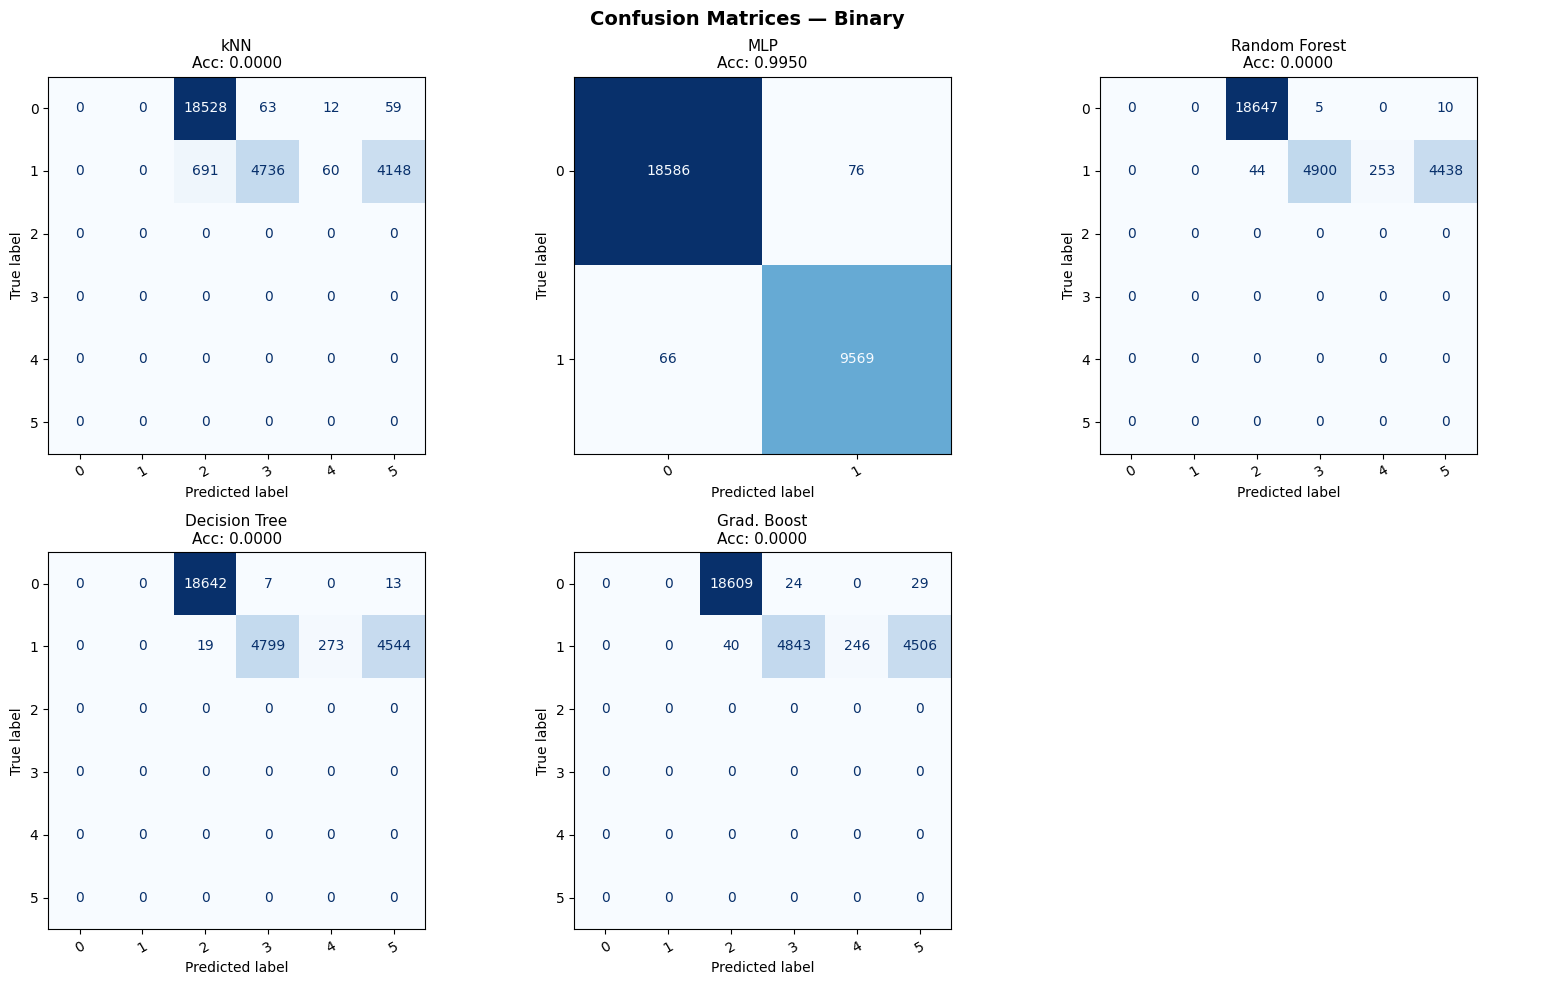

Saved!


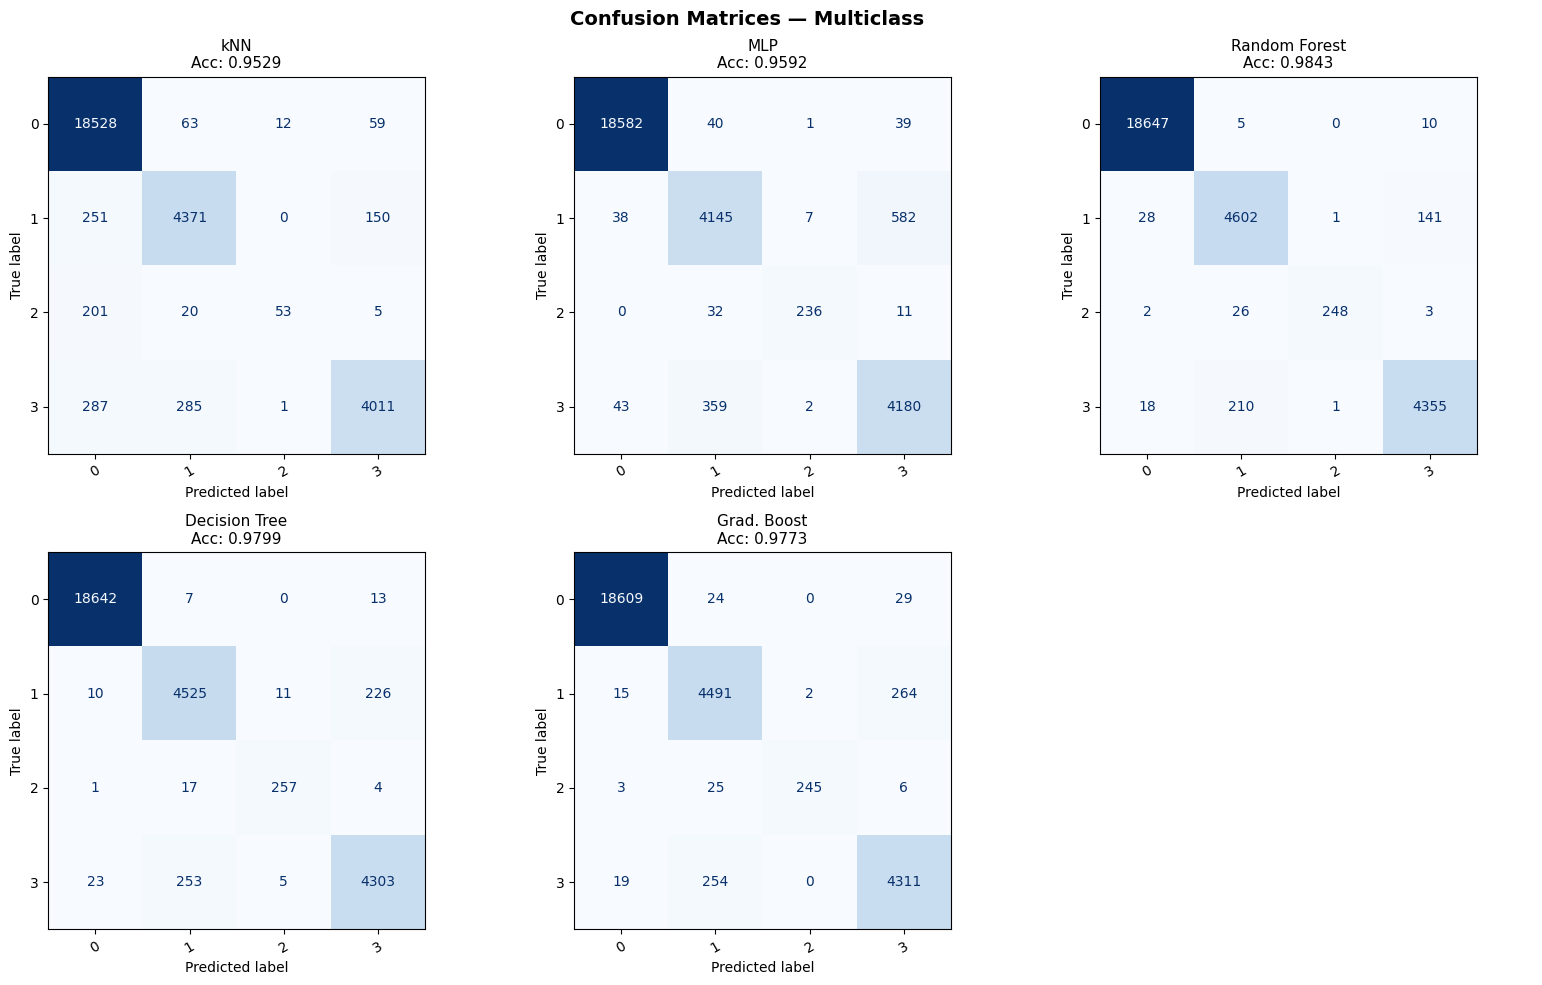

Saved!

Phase 6 complete!


In [18]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# ── Helper: pick correct test set (MLP needs scaled data) 
def get_test_data(name, case):
    if name == 'MLP':
        return (X_test_bin_scaled, y_test_bin) if case == 1 else (X_test_mul_scaled, y_test_mul)
    return (X_test_bin, y_test_bin) if case == 1 else (X_test_mul, y_test_mul)

#  Helper: evaluate all models for one case
def evaluate_models(trained, case_num, case_name):
    print(f"\n{'='*65}")
    print(f"  {case_name}")
    print(f"{'='*65}")
    print(f"  {'Model':<20} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F-score':>9}")
    print(f"  {'-'*58}")

    results = {}
    for name, model in trained.items():
        X_test, y_test = get_test_data(name, case_num)
        y_pred = model.predict(X_test)

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        results[name] = {'accuracy': acc, 'precision': prec,
                         'recall': rec,  'f1': f1, 'y_pred': y_pred}

        print(f"  {name:<20} {acc:>8.4f}  {prec:>9.4f}  {rec:>7.4f}  {f1:>8.4f}")

    return results

#Evaluate both cases 
results_bin = evaluate_models(trained_bin, 1, "Case 1 — Binary (Benign vs Darknet)")
results_mul = evaluate_models(trained_mul, 2, "Case 2 — Multiclass (Tor/Non-Tor/VPN/Non-VPN)")

# ── Plot Confusion Matrices
def plot_confusion_matrices(trained, results, y_test, case_name):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    fig.suptitle(f'Confusion Matrices — {case_name}', fontsize=14, fontweight='bold')

    for i, (name, model) in enumerate(trained.items()):
        y_pred = results[name]['y_pred']
        cm = confusion_matrix(y_test, y_pred)
        
        # FIX: don't pass display_labels — let it use the cm directly
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
        axes[i].set_title(f'{name}\nAcc: {results[name]["accuracy"]:.4f}',
                          fontsize=11)
        axes[i].tick_params(axis='x', rotation=30)

    axes[5].axis('off')
    plt.tight_layout()
    plt.savefig(f'confusion_matrices_{"binary" if "Binary" in case_name else "multi"}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved!")

plot_confusion_matrices(trained_bin, results_bin, y_test_bin, "Binary")
plot_confusion_matrices(trained_mul, results_mul, y_test_mul, "Multiclass")

print("\nPhase 6 complete!")